# MCMC for hierarchical Bayesian models

**Day 3, 11:00 — 60 minutes.** Alexander Fengler (with Brandon Turner).

The motivating slides are
[here](hierarchical-mcmc-slides.qmd). This notebook is the hands-on half.

Yesterday afternoon we saw posteriors that were hard because they were
**correlated** — a long thin ridge, but the same shape everywhere. Hierarchical
models bring a nastier relative: **curvature that changes as you move**. No
single step size works everywhere, and the failure is not slowness. It is
*bias*.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-hierarchy"))
rng = np.random.default_rng(RANDOM_SEED)

DRAWS, TUNE, CHAINS = 1000, 1000, 4

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## 1. First: why would you want a hierarchy at all?

Most of this session is about a *problem* hierarchical models create. That
ordering is misleading unless we first establish what they buy you, so start
there.

The setting is the one real cognitive data is always in: **unbalanced**. Some
participants completed hundreds of trials, some barely turned up.

In [2]:
import sbi4cogsci_figures as F      # shared with the slide deck — one source

pool = F.pooling_experiment(seed=RANDOM_SEED)
counts = pool["trial_counts"]
print(f"{counts.size} participants, {pool['n_trials_total']} trials total")
print(f"trials per participant: {counts.min()} to {counts.max()}")
print(f"  the five thinnest: {sorted(counts)[:5]}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu_v, tau_v, z_off]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


20 participants, 3081 trials total
trials per participant: 5 to 600
  the five thinnest: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]


Each participant has their own drift rate, drawn from a population. We fit the
same data twice — **no pooling** (each participant estimated alone) and
**partial pooling** (participants drawn from an estimated population) — and
compare both against the drift rates we actually used.

`a`, `z` and `t` are held at their true values so that the comparison is about
pooling and nothing else.

In [3]:
summary = F.pooling_summary(pool)
print(f"{'':18s} {'MAE (all)':>10s} {'n < 30':>10s} {'n >= 30':>10s}")
for key, label in [("no_pooling", "no pooling"), ("partial_pooling", "partial pooling")]:
    d = summary[key]
    print(f"{label:18s} {d['mae_all']:10.3f} {d['mae_low']:10.3f} {d['mae_high']:10.3f}")
print(f"\nimprovement where trials < 30: {summary['low_n_improvement_pct']:.0f}%")

                    MAE (all)     n < 30    n >= 30
no pooling              0.158      0.265      0.051
partial pooling         0.114      0.175      0.052

improvement where trials < 30: 34%


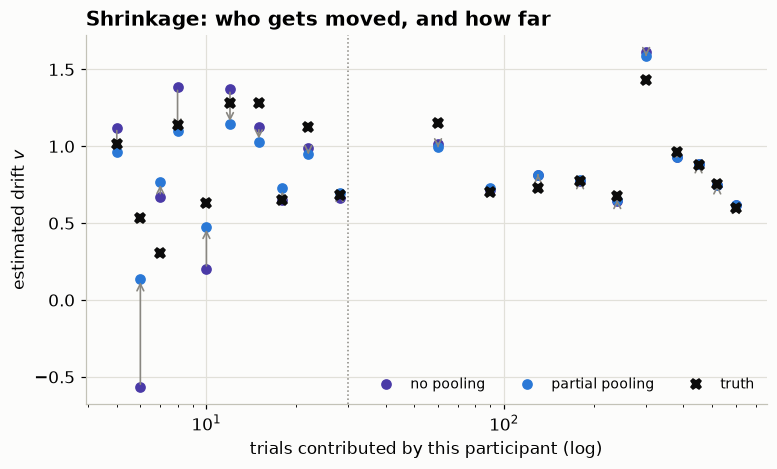

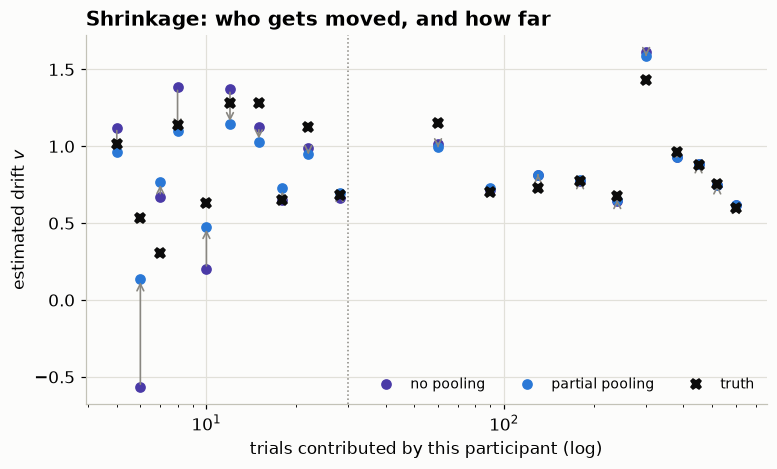

In [4]:
F.fig_shrinkage(pool)

Every arrow is one participant, running from their no-pooling estimate to
their partial-pooling one. The arrows are long on the left and invisible on
the right: **pooling moves exactly the participants who could not speak for
themselves, and leaves the others alone.**

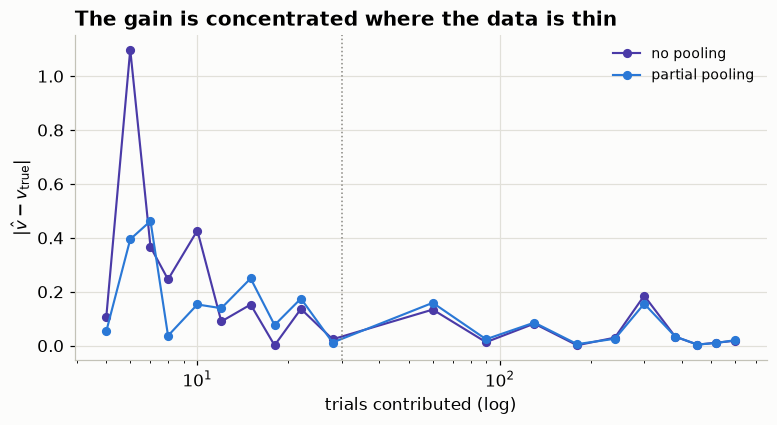

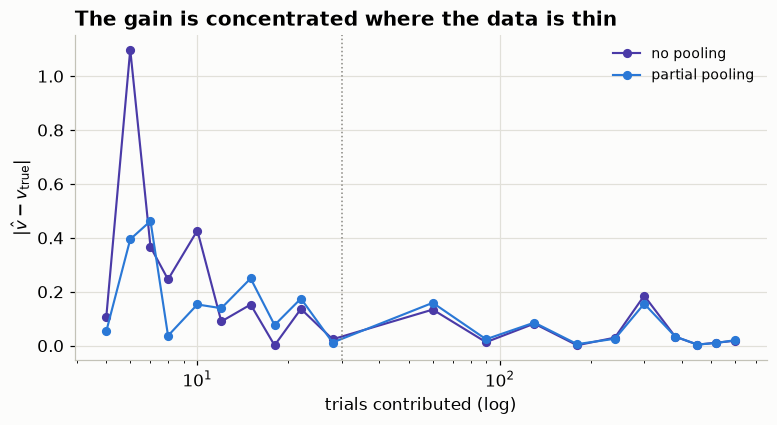

In [5]:
F.fig_pooling_error(pool)

::: {.callout-note}
## What pooling actually is
With five trials, a no-pooling estimate has almost no information to work
with, so it falls back on whatever prior you happened to write down. Partial
pooling also falls back on a prior — but on the **population**, estimated from
the participants who did have data.

**Pooling replaces an arbitrary prior with an earned one.** That is the whole
idea, and everything after this is the price you pay for it.
:::

> **Poll.** Partial pooling improved the sparse participants a lot and the
> dense ones not at all. Why not at all?
>
> **A.** The sampler converged better for them.
> **B.** Their likelihood already dominates the prior, so shrinkage has
>   almost nothing to pull against.
> **C.** The population distribution does not apply to them.
> **D.** They were closer to the population mean to begin with.

<details>
<summary>Answer</summary>

**B.** Shrinkage weight is roughly $\tau^2 / (\tau^2 + \mathrm{se}_g^2)$ — it
depends on how precise *that participant's* own estimate is. With 600 trials
the standard error is tiny, the weight goes to ~1, and the estimate barely
moves. With 5 trials the standard error is large and the population wins.

Hold on to this: it is the same quantity that decides which
**parameterization** each group wants, later in this notebook.

</details>

### Did we not just add parameters?

Counted naively, partial pooling is the **bigger** model — it has everything
no-pooling has, plus $\mu$ and $\tau$. And it generalised better. Either
Occam's razor is wrong, or we are counting the wrong thing.

The right thing to count is the **effective** number of parameters, `p_loo`,
which we already computed above.

In [6]:
print(f"{'':18s} {'nominal':>9s} {'effective (p_loo)':>19s}")
for key, label in [("no_pooling", "no pooling"), ("partial_pooling", "partial pooling")]:
    print(f"{label:18s} {pool['nominal'][key]:9d} {pool['p_loo'][key]:19.1f}")

                     nominal   effective (p_loo)
no pooling                20                19.2
partial pooling           22                15.1


Two more nominal parameters; roughly **four fewer effective** ones.

A parameter costs a full unit only if the data is free to put it anywhere.
Under pooling each $v_g$ is pulled toward $\mu$, so it is no longer free — it
costs a *fraction* of a parameter. The two hyperparameters are not two extra
freedoms; they are two knobs that **remove** freedom from the other twenty,
and $\tau$ is a regularisation strength *learned from the data* rather than
guessed by you.

::: {.callout-warning}
## Two honest caveats before you quote this number
**The gap depends on how sparse your groups are.** Ours has participants with
five trials, and those shrink hard. Re-run with 600 trials for everyone and
the gap nearly closes: each participant's own data identifies their drift,
shrinkage has nothing to pull against, and `p_loo` approaches the nominal
count. The effective-parameter story is a statement about *your data*, not
about hierarchical models in the abstract.

**`elpd_loo` was essentially a tie.** Trial-level LOO is dominated by the
participants who had plenty of trials, so it barely notices the improvement
for the sparse ones. Fewer effective parameters, same trial-level predictive
score — the benefit showed up in the **estimates**, which is what we measured
before. If you care about generalising to a *new participant*, the matching
quantity is leave-one-participant-out, not this.
:::

::: {.callout-note}
## ArviZ 1.x naming
`az.loo(idata)` returns an object whose attribute is **`.p`**, although it
*prints* as `p_loo`. And `az.waic` no longer exists — ArviZ 1.0 removed it in
favour of PSIS-LOO. Nearly every tutorial you find online predates this.
:::

## 2. Neal's funnel — the geometry, before any data

Neal (2003) reduced the whole problem to two lines:

$$v \sim \text{Normal}(0, 3), \qquad x_i \mid v \sim \text{Normal}\!\left(0, e^{v/2}\right)$$

There is no data and no likelihood. This is a *prior* — the shape a
hierarchical model has before the data says anything. `v` plays the role of
a log population scale, and `x` the role of group-level parameters.

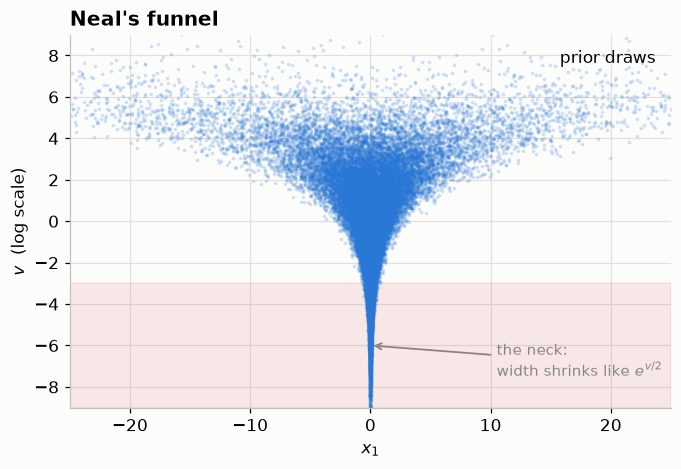

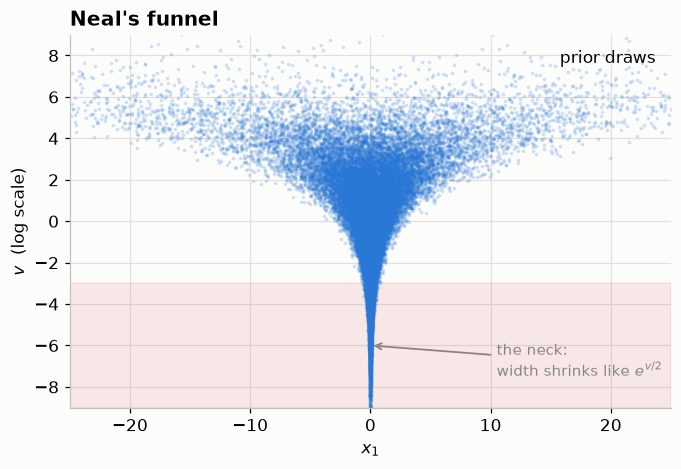

In [7]:
# Same function the slide deck bakes its copy of this figure from.
x_prior, v_prior = F.funnel_draws(n=40_000, sd_v=3.0, seed=RANDOM_SEED)
F.fig_funnel(x_prior, v_prior)

At $v = 2$ the conditional standard deviation of $x$ is $e^{1} \approx 2.7$.
At $v = -6$ it is $e^{-3} \approx 0.05$ — **fifty times narrower**. A step size
tuned for the mouth is wildly unstable in the neck; one tuned for the neck
would take forever to cross the mouth.

::: {.callout-important}
## The failure mode is bias, not slowness
A sampler that cannot enter the neck does not merely explore it *slowly* — it
systematically **never goes there**, so every posterior expectation is wrong.
And $\hat{R}$ cannot see this, because all the chains fail the same way.
:::

## 3. Sampling it, both ways

**Centered** — sample $x$ directly, with its scale depending on $v$:

$$v \sim \text{Normal}(0,3), \qquad x \sim \text{Normal}(0, e^{v/2})$$

**Non-centered** — sample a standard normal and rescale it:

$$v \sim \text{Normal}(0,3), \qquad \tilde{x} \sim \text{Normal}(0,1),
  \qquad x = e^{v/2}\,\tilde{x}$$

These describe the *same distribution*. They are different **coordinate
systems** for it, and the sampler only ever sees the coordinates.

In [8]:
def funnel_centered(dim=1):
    with pm.Model() as m:
        v = pm.Normal("v", 0.0, 3.0)
        pm.Normal("x", 0.0, pm.math.exp(v / 2), shape=dim)
    return m


def funnel_noncentered(dim=1):
    with pm.Model() as m:
        v = pm.Normal("v", 0.0, 3.0)
        x_tilde = pm.Normal("x_tilde", 0.0, 1.0, shape=dim)
        pm.Deterministic("x", pm.math.exp(v / 2) * x_tilde)
    return m


def sample(model, seed=RANDOM_SEED, **kw):
    with model:
        return pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
                         nuts_sampler="pymc", progressbar=False,
                         random_seed=seed, **kw)


idata_c = sample(funnel_centered())
idata_n = sample(funnel_noncentered())

for name, idata in [("centered", idata_c), ("non-centered", idata_n)]:
    div = int(idata.sample_stats["diverging"].values.sum())
    v = idata.posterior.dataset["v"].values
    print(f"{name:13s} divergences {div:5d}   "
          f"min v reached {v.min():6.2f}   mean v {v.mean():+.3f}  (true mean 0)")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 276 divergences after tuning. Increase `target_accept` or reparameterize.


...

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x_tilde]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


centered      divergences   276   min v reached  -3.91   mean v +0.960  (true mean 0)
non-centered  divergences     0   min v reached -11.35   mean v +0.006  (true mean 0)


### The plot that shows it

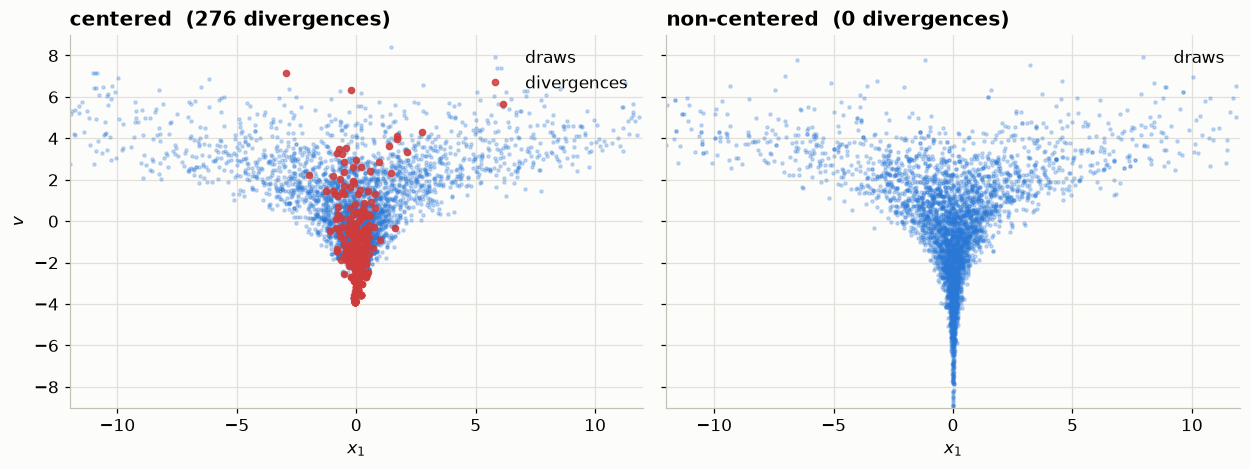

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True, sharey=True)
for ax, (name, idata) in zip(axes, [("centered", idata_c), ("non-centered", idata_n)]):
    post = idata.posterior.dataset
    v = post["v"].values.ravel()
    x = post["x"].values.reshape(v.size, -1)[:, 0]
    div = idata.sample_stats["diverging"].values.ravel()
    ax.plot(x, v, "o", color=S.PRIMARY, ms=2, alpha=0.25, ls="none", label="draws")
    if div.any():
        S.divergences(ax, x[div], v[div])
    ax.set(title=f"{name}  ({int(div.sum())} divergences)",
           xlabel="$x_1$", xlim=(-12, 12), ylim=(-9, 9))
    ax.legend(loc="upper right")
axes[0].set_ylabel("$v$")
fig.tight_layout()

The divergences are not scattered at random — they **cluster in the neck**,
which is precisely the region the centered chain then under-samples.

> **Poll.** The centered run reports $\hat{R} = 1.00$ for `v`. What does that
> tell you?
>
> **A.** The chains converged; the divergences are a performance warning.
> **B.** Nothing useful — all four chains can fail in the same way.
> **C.** It means the model is correctly specified.
> **D.** It means we need more draws.

<details>
<summary>Answer</summary>

**B.** $\hat{R}$ compares chains to each other. If every chain stops at the
same place for the same geometric reason, they agree beautifully — about the
wrong answer. This is why divergences are a *separate* diagnostic and why
"$\hat{R}$ is fine" is not a clean bill of health.

</details>

### Proving it is bias

Efficiency problems shrink as you run longer. Bias does not. Track the running
mean of `v` — we know the true value is 0.

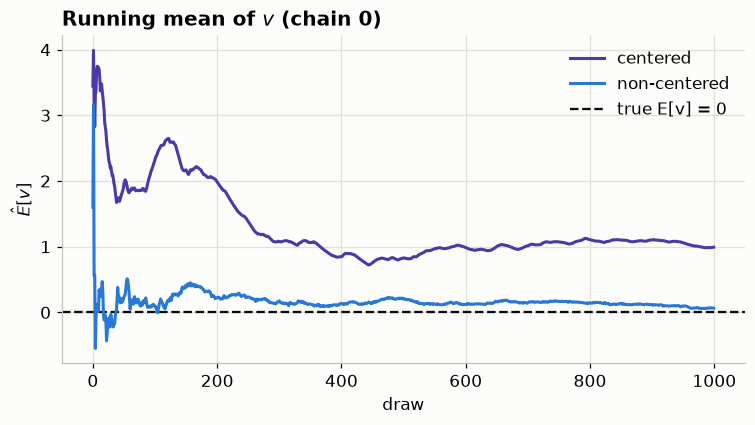

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, idata, colour in [("centered", idata_c, S.NAIVE),
                            ("non-centered", idata_n, S.PRIMARY)]:
    v = idata.posterior.dataset["v"].values[0]
    ax.plot(np.cumsum(v) / np.arange(1, v.size + 1), color=colour, label=name)
S.truth_line(ax, 0.0, label="true E[v] = 0")
ax.set(title="Running mean of $v$ (chain 0)", xlabel="draw", ylabel=r"$\hat{E}[v]$")
ax.legend()
fig.tight_layout()

The centered chain settles at the wrong value and **stays** there. Running it
ten times longer moves it ten times more slowly toward nothing in particular.

### What about just raising `target_accept`?

In [11]:
rows = []
for ta in [0.8, 0.95, 0.99]:
    idata = sample(funnel_centered(), nuts={"target_accept": ta})
    v = idata.posterior.dataset["v"].values
    rows.append({"target_accept": ta,
                 "divergences": int(idata.sample_stats["diverging"].values.sum()),
                 "min v reached": v.min(),
                 "mean v (true 0)": v.mean()})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:8.3f}"))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 276 divergences after tuning. Increase `target_accept` or reparameterize.


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


There were 27 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


 target_accept  divergences  min v reached  mean v (true 0)
         0.800          276         -3.914            0.960
         0.950          117         -5.752           -0.195
         0.990           27         -7.329            0.284


Divergences drop. The estimate does not become correct. **Raising
`target_accept` suppresses the symptom, not the geometry** — it is a
diagnostic aid, not a fix. The fix is to change coordinates.

## 4. Non-centered is not always better

This is the part most tutorials get wrong. The choice depends on whether the
**prior** or the **likelihood** dominates each group's posterior
(Papaspiliopoulos, Roberts & Sköld 2007; Betancourt & Girolami 2013):

- **little data per group** → prior dominates → **non-centered** wins
- **lots of data per group** → likelihood dominates → **centered** wins

Let us find the crossover instead of taking it on faith. A standard
hierarchical normal, sweeping the number of observations per group.

In [12]:
N_GROUPS, TRUE_MU, TRUE_TAU, OBS_SIGMA = 8, 0.0, 1.0, 1.0


def make_groups(obs_per_group, seed):
    g = np.random.default_rng(seed)
    theta = g.normal(TRUE_MU, TRUE_TAU, N_GROUPS)
    y = g.normal(theta[:, None], OBS_SIGMA, (N_GROUPS, obs_per_group))
    return y.mean(axis=1), OBS_SIGMA / np.sqrt(obs_per_group)


def hier_centered(y_bar, se):
    with pm.Model() as m:
        mu = pm.Normal("mu", 0.0, 5.0)
        tau = pm.HalfNormal("tau", 5.0)
        theta = pm.Normal("theta", mu, tau, shape=N_GROUPS)
        pm.Normal("y", theta, se, observed=y_bar)
    return m


def hier_noncentered(y_bar, se):
    with pm.Model() as m:
        mu = pm.Normal("mu", 0.0, 5.0)
        tau = pm.HalfNormal("tau", 5.0)
        z = pm.Normal("z", 0.0, 1.0, shape=N_GROUPS)
        theta = pm.Deterministic("theta", mu + tau * z)
        pm.Normal("y", theta, se, observed=y_bar)
    return m


sweep = []
for obs in [1, 3, 10, 30, 100]:
    y_bar, se = make_groups(obs, seed=RANDOM_SEED + obs)
    for label, builder in [("centered", hier_centered),
                           ("non-centered", hier_noncentered)]:
        idata = sample(builder(y_bar, se))
        grads = idata.sample_stats["n_steps"].values.sum() \
            if "n_steps" in idata.sample_stats else np.nan
        ess = float(az.ess(idata, var_names=["tau"]).tau)
        sweep.append({"obs/group": obs, "param": label,
                      "divergences": int(idata.sample_stats["diverging"].values.sum()),
                      "ESS(tau)": ess,
                      "ESS per 1k grads": 1000 * ess / grads if grads == grads else np.nan})

sweep = pd.DataFrame(sweep)
print(sweep.to_string(index=False, float_format=lambda x: f"{x:9.2f}"))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, tau, theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 236 divergences after tuning. Increase `target_accept` or reparameterize.


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


 obs/group        param  divergences  ESS(tau)  ESS per 1k grads
         1     centered          236     15.41              0.38
         1 non-centered            4    906.91             21.12
         3     centered           15   1969.23             72.26
         3 non-centered            0    948.44             23.50
        10     centered            0   3224.16            121.75
        10 non-centered            0    686.19             13.14
        30     centered            0   3919.49            151.61
        30 non-centered            2    662.00             10.21
       100     centered            0   3498.52            139.22
       100 non-centered           10    316.76              2.87


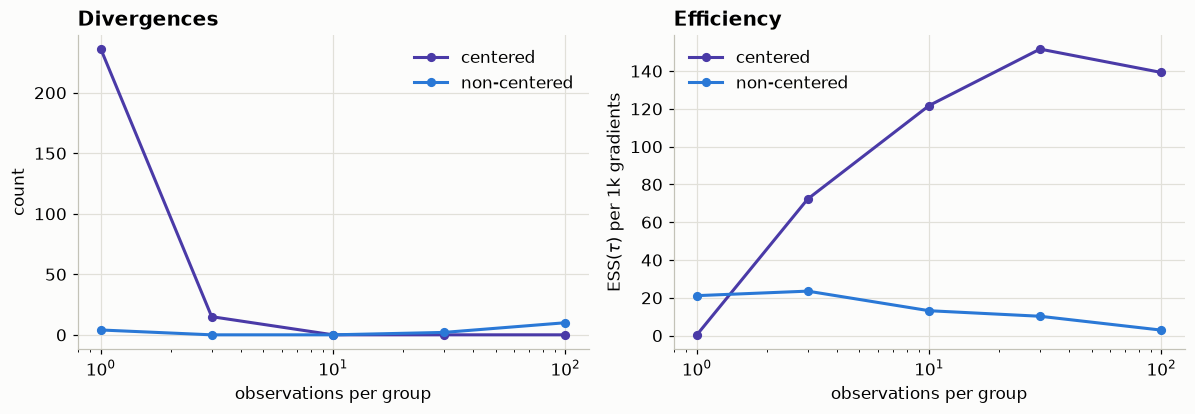

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.9))
for label, colour in [("centered", S.NAIVE), ("non-centered", S.PRIMARY)]:
    sub = sweep[sweep.param == label]
    ax1.plot(sub["obs/group"], sub["divergences"], "o-", color=colour, label=label)
    ax2.plot(sub["obs/group"], sub["ESS per 1k grads"], "o-", color=colour, label=label)
ax1.set(title="Divergences", xlabel="observations per group", xscale="log",
        ylabel="count")
ax1.legend()
ax2.set(title="Efficiency", xlabel="observations per group", xscale="log",
        ylabel=r"ESS($\tau$) per 1k gradients")
ax2.legend()
fig.tight_layout()

::: {.callout-note}
## The rule, stated properly
"Always non-center hierarchical models" is the single most widespread piece of
wrong advice in applied Bayesian work. The correct statement is: **non-center
the parameters whose groups are data-poor.** With enough data per group the
centered form is better behaved, because then the likelihood — not the prior —
is what shapes each group's posterior.

Which is why you want the choice to be **per parameter**.
:::

### What that looks like in the geometry

The ESS curves say *that* the advantage reverses. This says *why*. Four fits —
both parameterizations, at weak and strong data — each plotted in the
coordinates its own sampler actually works in, against $\log\tau$, with
divergences overlaid.

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, tau, theta]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 1 seconds.


There were 350 divergences after tuning. Increase `target_accept` or reparameterize.


...

Sequential sampling (4 chains in 1 job)


NUTS: [mu, tau, z]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 5 seconds.


There were 16 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


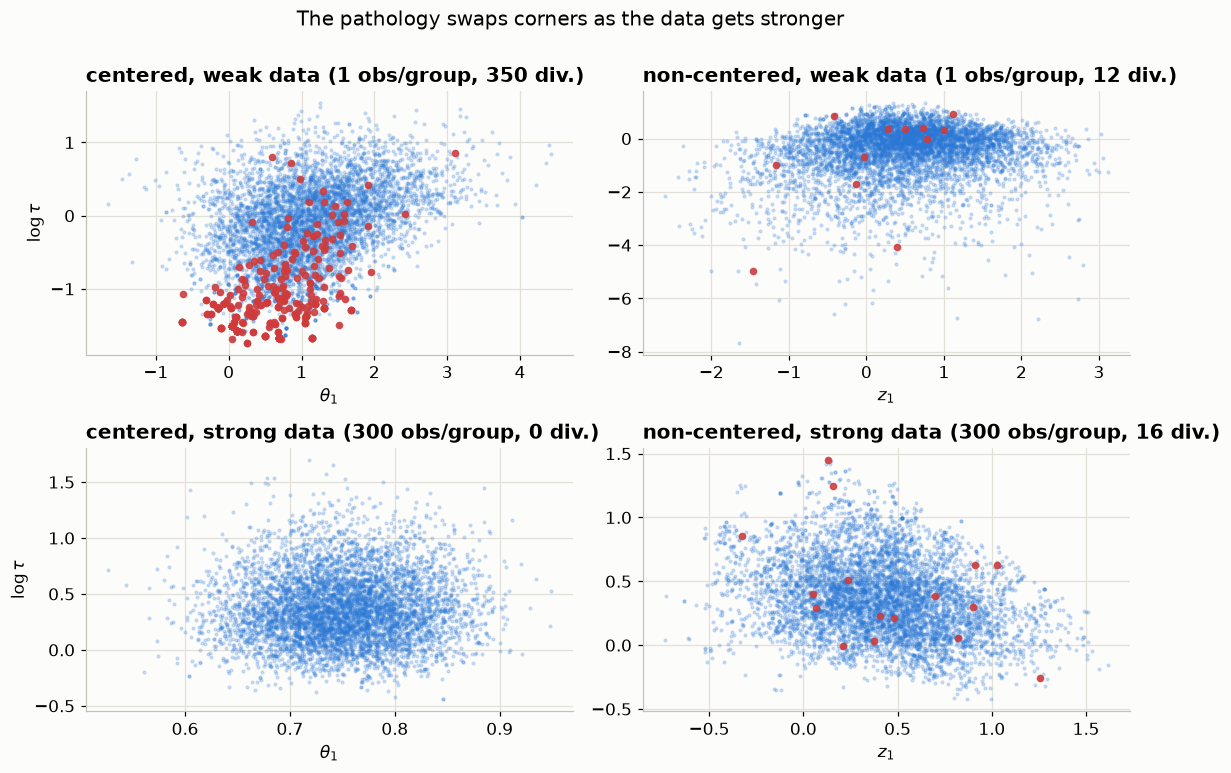

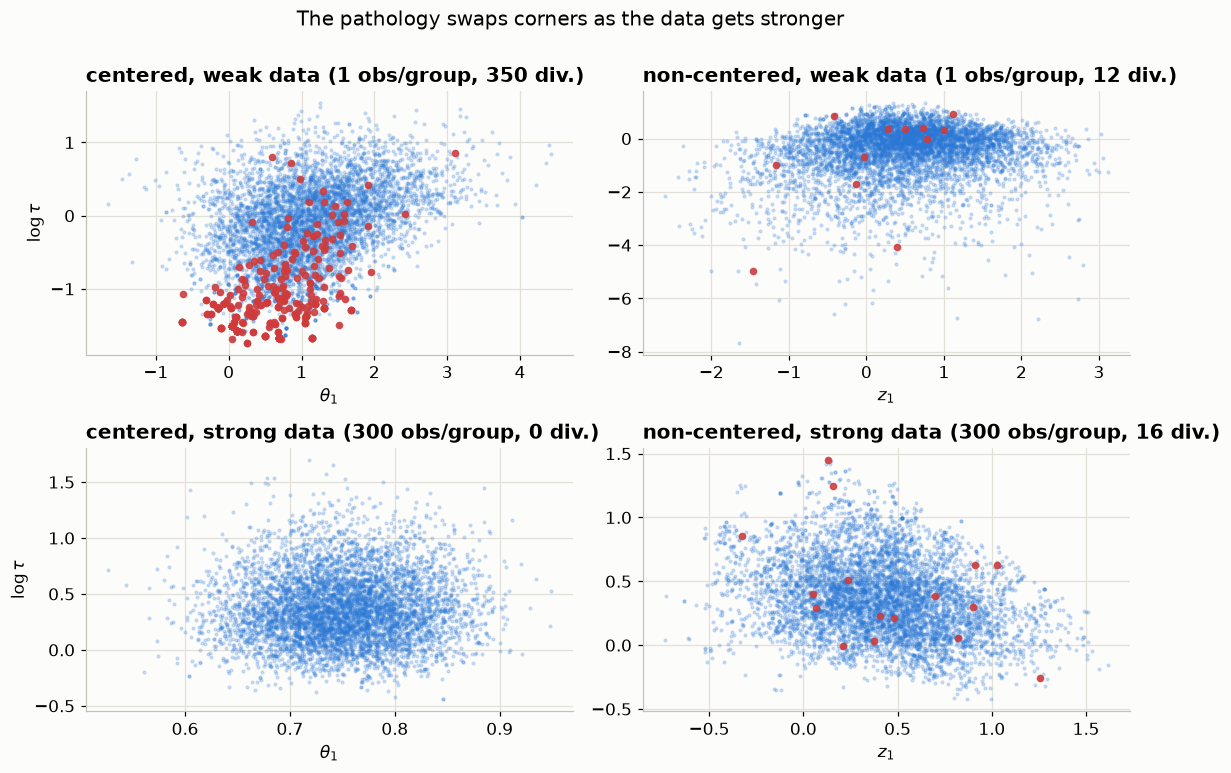

In [14]:
geom = F.geometry_experiment(seed=RANDOM_SEED)
F.fig_geometry_grid(geom)

In [15]:
print(f"{'parameterization':16s} {'obs/group':>10s} {'divergences':>12s}")
for (n_obs, par), d in geom["results"].items():
    print(f"{par:16s} {n_obs:10d} {d['n_divergences']:12d}")

parameterization  obs/group  divergences
centered                  1          350
non-centered              1           12
centered                300            0
non-centered            300           16


Read the four panels as a 2×2. **Top-left**: the classic funnel, pinching
downward, divergences packed into the neck. **Bottom-right**: the mirror
image — an *inverted* funnel, where holding $\theta_g$ fixed while $\tau$
grows forces $z_g$ to shrink, and the divergences sit at the **top**.

The diagonal is the lesson. Centered is catastrophic with weak data and
flawless with strong data; non-centered does not improve as data accumulates,
it gets slightly worse.

::: {.callout-note}
## And yet non-centered is still the sensible default
The inverted funnel is *suppressed by partial pooling itself* — the more
groups there are informing $\tau$, the more its bad end gets cut off.
Betancourt puts it sharply: **"the pathological behavior is the worst exactly
when the partial pooling is strongest."** So the reversal usually costs you
efficiency rather than correctness, which is why "non-center by default, and
reconsider when a group is data-rich" is reasonable advice.
:::

::: {.callout-warning}
## Do not memorise the crossover point
This sweep holds the **number of groups fixed at 8** and varies only the
observations within each. The crossover also moves with the number of groups,
the group-scale prior, and how much the groups actually differ — so "the
crossover is at 3 observations" is a fact about *this* setup, not a constant.

What transfers is the *shape*: two curves that cross, and a rule for which
side you are on. Run the sweep on your own model rather than importing a
number from someone else's.
:::

## 5. Per-parameter parameterization in HSSM

A real SSM has parameters of both kinds in the same model. Drift `v` is often
estimated from plenty of trials per participant; a boundary or non-decision
time may be far more weakly identified. HSSM lets you choose independently.

In [16]:
import hssm

data = hssm.load_data("cavanagh_theta")
print(data.head(3).to_string(index=False))
print("\nparticipants:", data["participant_id"].nunique(), " trials:", len(data))

 participant_id stim   rt  response     theta  dbs conf
              0   LL 1.21       1.0  0.656275    1   HC
              0   WL 1.63       1.0 -0.327889    1   LC
              0   WW 1.03       1.0 -0.480285    1   HC

participants: 14  trials: 3988


`noncentered` is not an HSSM argument — it passes straight through to
`bmb.Model`. It takes a bool **or a dict keyed by parameter**, and a
per-prior setting overrides the dict:

```
resolution order:  prior.noncentered  >  noncentered[param]  >  True
```

In [17]:
def build(noncentered):
    return hssm.HSSM(
        data=data,
        model="ddm",
        noncentered=noncentered,
        include=[
            {"name": "v", "formula": "v ~ 1 + (1|participant_id)"},
            {"name": "a", "formula": "a ~ 1 + (1|participant_id)"},
        ],
        p_outlier=0.05,          # explicit: this is the default, not "off"
        prior_settings="safe",
    )


mixed = build({"v": False, "a": True})

# The PyMC graph is materialised at construction — `model.pymc_model` is ready
# to inspect, and there is no `.build()` to call.
participant_nodes = sorted(n for n in mixed.pymc_model.named_vars
                           if "participant_id" in n)
print("participant-level nodes:")
for n in participant_nodes:
    mark = "  <- non-centered" if n.endswith("_offset") else ""
    print(f"    {n}{mark}")

Model initialized successfully.


participant-level nodes:
    a_1|participant_id
    a_1|participant_id_offset  <- non-centered
    a_1|participant_id_sigma
    v_1|participant_id
    v_1|participant_id_sigma


The `_offset` nodes are the structural fingerprint of the non-centered
parameterization: `u_g = z_g · σ`. `a` has one, `v` does not — exactly what we
asked for. You can read the parameterization off the graph without sampling
anything.

::: {.callout-warning}
## Two ways this bites
**Non-centering only works for `Normal` priors whose `sigma` is itself a
random variable.** Anything else raises `NotImplementedError` when the model
is built — loud, at least.

**The quiet one:** a `Normal` group prior with a nested `mu` hyperprior under
non-centering leaves `mu` as a **disconnected free variable** — sampled, but
influencing nothing. HSSM 0.4.0 ships detectors for this
(`check_user_priors_against_parameterization`, `find_disconnected_free_rvs`).
Always check `print(model)` / `model.graph()` after changing parameterization,
because term-prior keys differ between the two forms and a mismatched key is
**silently dropped**.
:::

### Exercise

Build the same model with `noncentered=True` and with `noncentered=False`, and
confirm from the graph alone (no sampling) which nodes change. Then predict —
before running anything — which setting you would want for `v` in the Cavanagh
data, given its 3,988 trials spread over 14 participants.

<details>
<summary>Solution and reasoning</summary>

```python
for setting in [True, False]:
    m = build(setting)
    offs = sorted(n for n in m.pymc_model.named_vars if n.endswith("_offset"))
    print(setting, "->", offs)
```

With roughly 285 trials per participant, the drift rate is well identified
*within* each participant — the likelihood dominates, so **centered** is the
better choice for `v`. Parameters that are weakly constrained per participant,
or a group scale estimated from only 14 groups, are the ones that want
non-centering. This is the crossover from section 3, in a real model.

</details>

## 6. Where this goes next

Centered and non-centered are the two endpoints of a continuum. **VIP**
(variationally inferred parametrization; Gorinova, Moore & Hoffman, ICML 2020)
learns a per-variable $\lambda \in [0,1]$:

$$\tilde{\theta} \sim \text{Normal}\!\left(\lambda\mu,\ \sigma^{\lambda}\right),
  \qquad
  \theta = \mu + \sigma^{1-\lambda}\left(\tilde{\theta} - \lambda\mu\right)$$

Check the endpoints, because the convention is easy to get backwards:
$\lambda = 1$ gives $\theta = \tilde{\theta} \sim \text{Normal}(\mu, \sigma)$,
which is **centered**; $\lambda = 0$ gives $\theta = \mu + \sigma\tilde{\theta}$
with $\tilde{\theta} \sim \text{Normal}(0,1)$, which is **non-centered**.

The optimiser picks the point in between for **each** variable, and the paper
reports a "modest but real" gain at intermediate $\lambda$ when the data is
neither weak nor strong. It is available in PyMC as
`pymc_extras.model.transforms.autoreparam.vip_reparametrize`.

::: {.callout-note}
## The experts disagree about how much this buys you
Betancourt's position is that "for any given likelihood function a
partially-centered parameterization may perform better … but in practice the
differences are usually negligible." Gorinova et al. measure a real if modest
improvement. Both can be true: **which groups** you center matters far more
than how precisely you center each one — which is the next section.
:::

## What to take away

- A hierarchical posterior has **position-dependent curvature**. That is a
  different problem from correlation, and it needs a different fix.
- Divergences mean **bias**, not slowness. $\hat{R}$ and ESS cannot see it.
- Raising `target_accept` removes the warning, not the cause.
- **Non-centered is not universally better.** Data-poor groups want
  non-centered; data-rich groups want centered.
- In HSSM, choose per parameter with `noncentered={"v": False, "a": True}`,
  and verify it from the `_offset` nodes in the graph.

### References

- Neal, R. (2003). Slice sampling. *Annals of Statistics* 31(3), 705–767.
- Papaspiliopoulos, Roberts & Sköld (2007). A general framework for the
  parametrization of hierarchical models. *Statistical Science* 22(1), 59–73.
- Betancourt & Girolami (2013). Hamiltonian Monte Carlo for hierarchical
  models. [arXiv:1312.0906](https://arxiv.org/abs/1312.0906)
- Betancourt (2017). Diagnosing biased inference with divergences.
- Gorinova, Moore & Hoffman (2020). Automatic reparameterisation of
  probabilistic programs. *ICML*.